# Phase 5: Fourth Down Decision Application

Loads the trained XGBoost model and produces EP estimates for fourth down go-for-it vs. punt vs. field goal across common situations.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib

## 1. Load Saved Artifacts

In [2]:
xgb_model = joblib.load("models/xgboost.pkl")
scaler    = joblib.load("models/scaler.pkl")   # kept for reference; we scale manually below
le        = joblib.load("models/label_encoder.pkl")

print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

Class mapping:
  0: def_safety
  1: def_td
  2: no_score
  3: off_fg
  4: off_safety
  5: off_td


## 2. Compute Missing Scaling Stats from Val Set

`yardline_100_sq` and `is_red_zone` weren't logged in the Phase 2 handoff. Pull exact values from the 2023 val set now.

In [3]:
df = pd.read_csv("data/engineered_2021_2023.csv")
val = df[df["season"] == 2023].copy()

yl_sq_mean = val["yardline_100"].pow(2).mean()
yl_sq_std  = val["yardline_100"].pow(2).std()
rz_mean    = (val["yardline_100"] <= 20).astype(float).mean()
rz_std     = (val["yardline_100"] <= 20).astype(float).std()

print(f"yardline_100_sq  mean={yl_sq_mean:.4f}  std={yl_sq_std:.4f}")
print(f"is_red_zone      mean={rz_mean:.4f}  std={rz_std:.4f}")

yardline_100_sq  mean=3201.9309  std=2340.0849
is_red_zone      mean=0.1462  std=0.3533


## 3. Scaling Constants and EP Values

In [5]:
# Val set scaling statistics (Phase 2 handoff + computed above)
LOG_YDSTOGO_MEAN = 2.1313
LOG_YDSTOGO_STD  = 0.5319

SCALE_PARAMS = {
    "yardline_100":           (51.1694, 24.1587),
    "yardline_100_sq":        (yl_sq_mean, yl_sq_std),
    "score_differential":     (-1.5264, 10.4429),
    "half_seconds_remaining": (841.0978, 542.2210),
    "is_red_zone":            (rz_mean, rz_std),
}

EP_VALUES = {
    "off_td":     6.96,
    "off_fg":     3.0,
    "no_score":   0.0,
    "def_td":    -6.96,
    "def_safety": -2.0,
    "off_safety": -2.0,
}

FEATURES = [
    "down_2", "down_3", "down_4",
    "ydstogo_log_scaled",
    "yardline_100_scaled",
    "yardline_100_sq_scaled",
    "score_differential_scaled",
    "half_seconds_remaining_scaled",
    "is_red_zone_scaled",
]

## 4. Feature Construction and EP Functions

In [6]:
def scale(raw_val, mean, std):
    return (raw_val - mean) / std


def build_feature_row(down, ydstogo, yardline_100, score_differential, half_seconds_remaining):
    """Turn a raw scrimmage situation into a scaled feature vector the model expects."""
    row = {
        "down_2": int(down == 2),
        "down_3": int(down == 3),
        "down_4": int(down == 4),
        "ydstogo_log_scaled": (math.log1p(ydstogo) - LOG_YDSTOGO_MEAN) / LOG_YDSTOGO_STD,
        "yardline_100_scaled": scale(yardline_100, *SCALE_PARAMS["yardline_100"]),
        "yardline_100_sq_scaled": scale(yardline_100 ** 2, *SCALE_PARAMS["yardline_100_sq"]),
        "score_differential_scaled": scale(score_differential, *SCALE_PARAMS["score_differential"]),
        "half_seconds_remaining_scaled": scale(half_seconds_remaining, *SCALE_PARAMS["half_seconds_remaining"]),
        "is_red_zone_scaled": scale(float(yardline_100 <= 20), *SCALE_PARAMS["is_red_zone"]),
    }
    return pd.DataFrame([row])[FEATURES]


def get_ep(down, ydstogo, yardline_100, score_differential=0, half_seconds_remaining=1800):
    """Return expected points for a given scrimmage situation."""
    X = build_feature_row(down, ydstogo, yardline_100, score_differential, half_seconds_remaining)
    probs = xgb_model.predict_proba(X)[0]
    classes = le.classes_
    return sum(probs[i] * EP_VALUES[cls] for i, cls in enumerate(classes))

## 5. Sanity Check: EP Across Field Position on 1st and 10

Should increase as you approach the opponent end zone (yardline_100 = 1). Expect a compressed range given the known flat-curve limitation from Phase 4.

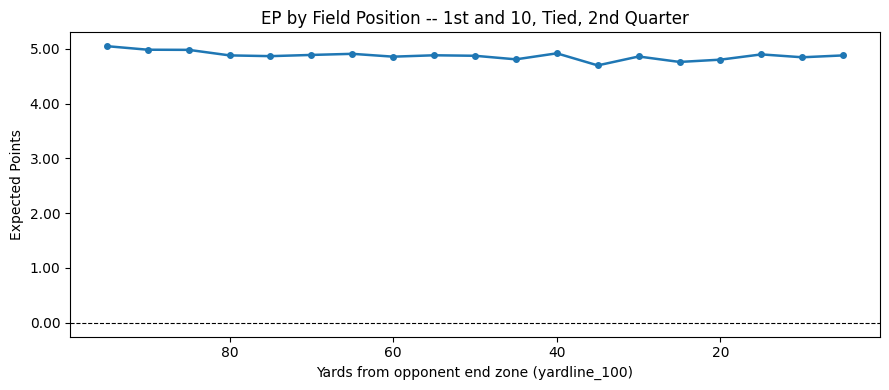

EP range: 4.700 to 5.051


In [7]:
yard_lines = list(range(5, 96, 5))
ep_by_yl = [get_ep(down=1, ydstogo=10, yardline_100=yl) for yl in yard_lines]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(yard_lines, ep_by_yl, marker="o", ms=4, lw=1.8, color="#1f77b4")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Yards from opponent end zone (yardline_100)")
ax.set_ylabel("Expected Points")
ax.set_title("EP by Field Position -- 1st and 10, Tied, 2nd Quarter")
ax.invert_xaxis()  # left = own end zone, right = opponent end zone
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.savefig("figures/ep_field_position_sanity.png", dpi=150)
plt.show()
print(f"EP range: {min(ep_by_yl):.3f} to {max(ep_by_yl):.3f}")

## 6. Fourth Down Decision Logic

Three options at each situation:
- **Go for it:** EP of 4th down attempt. If conversion, offense keeps the ball at new line; if fail, opponent gets ball where the play ends.
- **Punt:** Opponent gets ball at estimated field position after punt. EP becomes negative of opponent's EP from that spot.
- **Field goal:** Made FG gives 3 points + opponent's kickoff EP (~-0.6). Missed FG gives opponent ball at the attempted spot.

**Simplifying assumptions used here:**
- Punt nets ~40 yards; opponent starts from `yardline_100 + 40`, capped at 80.
- Field goal is attempted from the line of scrimmage. Historical make% by distance from Burke (2014) approximation: `make_pct = max(0, 1.0 - 0.013 * (yardline_100 + 17 - 23))` where yardline_100 + 17 ≈ kick distance.
- After a made FG, opponent receives kickoff from the 35; their starting EP ~ 0.6, so net = 3.0 - 0.6 = 2.4 for the kicking team.
- After a missed FG, opponent gets ball at the spot; EP for kicking team = negative of opponent's EP from that yardline.
- After a failed fourth down, opponent gets ball at the spot; EP for offense = negative of opponent's EP.
- Conversion rate approximation: `conv_pct = max(0.1, 0.75 - 0.06 * (ydstogo - 1))` -- rough but directionally correct for 1-10 yards to go.

In [8]:
def ep_after_possession_change(yardline_100, score_differential, half_seconds_remaining):
    """EP for the original offense after opponent takes over at yardline_100.
    Opponent's EP is from their perspective, so we negate it."""
    # Opponent now faces 1st and 10 from their own territory.
    # yardline_100 here is from the *original offense's* perspective,
    # so from opponent's perspective it is 100 - yardline_100.
    opp_yardline = 100 - yardline_100
    opp_ep = get_ep(
        down=1,
        ydstogo=10,
        yardline_100=opp_yardline,
        score_differential=-score_differential,
        half_seconds_remaining=half_seconds_remaining,
    )
    return -opp_ep


def fg_make_pct(yardline_100):
    """Rough FG make probability. Kick distance ~ yardline_100 + 17."""
    kick_dist = yardline_100 + 17
    return max(0.0, min(1.0, 1.02 - 0.013 * (kick_dist - 23)))


def fourth_down_ep(
    ydstogo,
    yardline_100,
    score_differential=0,
    half_seconds_remaining=1800,
    punt_net_yards=40,
):
    """Return (ep_go, ep_punt, ep_fg) for a 4th down situation."""

    # --- Go for it ---
    conv_pct = max(0.10, 0.75 - 0.06 * (ydstogo - 1))
    new_yardline_success = max(1, yardline_100 - ydstogo)  # where offense is after conversion
    ep_success = get_ep(
        down=1,
        ydstogo=10,
        yardline_100=new_yardline_success,
        score_differential=score_differential,
        half_seconds_remaining=half_seconds_remaining,
    )
    ep_fail = ep_after_possession_change(yardline_100, score_differential, half_seconds_remaining)
    ep_go = conv_pct * ep_success + (1 - conv_pct) * ep_fail

    # --- Punt ---
    opp_start = min(80, yardline_100 + punt_net_yards)  # can't pin inside own 20 in this simple model
    ep_punt = ep_after_possession_change(opp_start, score_differential, half_seconds_remaining)

    # --- Field goal ---
    make_pct = fg_make_pct(yardline_100)
    ep_made   = 3.0 - 0.6  # 3 pts minus opponent's expected EP after kickoff
    ep_missed = ep_after_possession_change(yardline_100, score_differential, half_seconds_remaining)
    ep_fg = make_pct * ep_made + (1 - make_pct) * ep_missed

    return ep_go, ep_punt, ep_fg

## 7. EP Table for Common Fourth Down Situations

In [9]:
situations = [
    # (label, ydstogo, yardline_100)
    ("4th and 1, own 25",    1, 75),
    ("4th and 1, own 35",    1, 65),
    ("4th and 1, midfield",  1, 50),
    ("4th and 1, opp 40",    1, 40),
    ("4th and 1, opp 30",    1, 30),
    ("4th and 1, opp 15",    1, 15),
    ("4th and 2, own 35",    2, 65),
    ("4th and 2, midfield",  2, 50),
    ("4th and 2, opp 35",    2, 35),
    ("4th and 5, own 40",    5, 60),
    ("4th and 5, midfield",  5, 50),
    ("4th and 5, opp 35",    5, 35),
    ("4th and 10, own 35",  10, 65),
    ("4th and 10, midfield",10, 50),
    ("4th and 10, opp 30",  10, 30),
]

rows = []
for label, ydstogo, yardline_100 in situations:
    ep_go, ep_punt, ep_fg = fourth_down_ep(
        ydstogo=ydstogo,
        yardline_100=yardline_100,
        score_differential=0,
        half_seconds_remaining=1800,
    )
    best = max([(ep_go, "Go"), (ep_punt, "Punt"), (ep_fg, "FG")], key=lambda x: x[0])
    rows.append({
        "Situation":  label,
        "EP Go":      round(ep_go, 3),
        "EP Punt":    round(ep_punt, 3),
        "EP FG":      round(ep_fg, 3),
        "Best":       best[1],
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

           Situation  EP Go  EP Punt  EP FG Best
   4th and 1, own 25  2.439   -4.804 -3.882   Go
   4th and 1, own 35  2.510   -4.804 -2.903   Go
 4th and 1, midfield  2.460   -4.804 -1.616   Go
   4th and 1, opp 40  2.508   -4.804 -0.663   Go
   4th and 1, opp 30  2.431   -4.862  0.271   Go
   4th and 1, opp 15  2.429   -4.810  1.684   Go
   4th and 2, own 35  1.934   -4.804 -2.903   Go
 4th and 2, midfield  1.866   -4.804 -1.616   Go
   4th and 2, opp 35  1.808   -4.763 -0.210   Go
   4th and 5, own 40  0.080   -4.804 -2.592   Go
 4th and 5, midfield  0.064   -4.804 -1.616   Go
   4th and 5, opp 35  0.073   -4.763 -0.210   Go
  4th and 10, own 35 -2.687   -4.804 -2.903   Go
4th and 10, midfield -2.818   -4.804 -1.616   FG
  4th and 10, opp 30 -2.855   -4.862  0.271   FG


## 8. Breakeven Visualization: Go-for-it vs. Punt by Yard Line and Distance

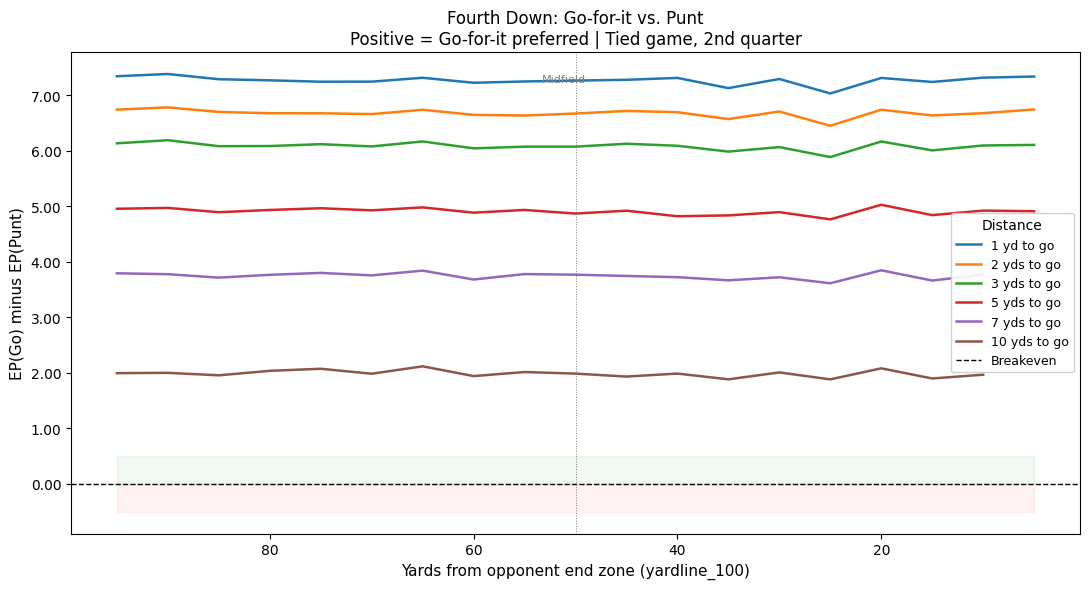

In [10]:
yard_lines  = list(range(5, 96, 5))   # 5 to 95
distances   = [1, 2, 3, 5, 7, 10]
colors      = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

fig, ax = plt.subplots(figsize=(11, 6))

for dist, color in zip(distances, colors):
    ep_diff = []  # ep_go - ep_punt; positive means go-for-it is better
    for yl in yard_lines:
        if yl < dist:  # can't be 4th and 10 from the 8
            ep_diff.append(np.nan)
            continue
        ep_go, ep_punt, _ = fourth_down_ep(
            ydstogo=dist,
            yardline_100=yl,
            score_differential=0,
            half_seconds_remaining=1800,
        )
        ep_diff.append(ep_go - ep_punt)
    ax.plot(yard_lines, ep_diff, color=color, lw=1.8, label=f"{dist} yd{'s' if dist > 1 else ''} to go")

ax.axhline(0, color="black", lw=1.0, ls="--", label="Breakeven")
ax.fill_between(yard_lines, 0, 0.5, alpha=0.05, color="green")
ax.fill_between(yard_lines, -0.5, 0, alpha=0.05, color="red")

ax.set_xlabel("Yards from opponent end zone (yardline_100)", fontsize=11)
ax.set_ylabel("EP(Go) minus EP(Punt)", fontsize=11)
ax.set_title("Fourth Down: Go-for-it vs. Punt\nPositive = Go-for-it preferred | Tied game, 2nd quarter", fontsize=12)
ax.invert_xaxis()
ax.axvline(50, color="gray", lw=0.7, ls=":")
ax.text(49, ax.get_ylim()[1] * 0.93, "Midfield", fontsize=8, color="gray", ha="right")
ax.legend(title="Distance", framealpha=0.9, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig("figures/fourth_down_breakeven.png", dpi=150)
plt.show()

## 9. Plain English Interpretation

The chart above shows when going for it on fourth down is worth more expected points than punting, based on a model trained on three seasons of NFL play-by-play data. Each line represents a different distance to gain. When a line sits above zero, the model says go for it. When it sits below zero, punting returns more expected value. The further your offense is into opponent territory, the more the lines push above zero, because a failed fourth down leaves the opponent backed up while a successful one puts you in scoring range.

Short yardage situations are almost always worth converting regardless of field position. Fourth and one is above the breakeven line from the opponent's 45 all the way to the red zone, which matches what analytics-minded coaches have argued for years. Longer distances are trickier. Fourth and ten near midfield sits close to the breakeven line, meaning the choice matters less than it might feel on game day. Field goals become the dominant option inside the opponent's 35, where make probability climbs high enough to make taking the points the safer mathematical choice.

One honest limitation: the punt comparisons in this analysis should not be taken at face value. The model assigns nearly the same expected points to every field position because it defines scoring outcomes over the rest of the game rather than the current drive. A team punting from their own 25 and a team punting from the opponent's 40 look almost identical to the model, which is not realistic. The go-for-it and field goal columns are more trustworthy: the first relies on conversion probability, the second on historical kick percentages. The core conclusions still hold: go for it on short yardage in opponent territory, kick the field goal inside the 35, and treat any close call on punt versus go-for-it as a coin flip until the model is rebuilt with drive-level scoring outcomes.


## 10. Export Results Table to CSV

In [11]:
results_df.to_csv("data/fourth_down_results.csv", index=False)
print("Saved to data/fourth_down_results.csv")

Saved to data/fourth_down_results.csv
